In [ ]:
# Import library yang diperlukan
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Membaca data
uploaded = files.upload()

Saving supermarket sales 2.csv to supermarket sales 2.csv


In [ ]:
data = pd.read_csv('supermarket sales 2.csv', delimiter=';')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice ID     1000 non-null   object 
 1   City           1000 non-null   object 
 2   Customer type  1000 non-null   object 
 3   Gender         1000 non-null   object 
 4   Product line   1000 non-null   object 
 5   Unit price     1000 non-null   float64
 6   Quantity       1000 non-null   int64  
 7   Total          1000 non-null   object 
 8   Date           1000 non-null   object 
 9   Time           1000 non-null   object 
 10  Payment        1000 non-null   object 
 11  Rating         1000 non-null   float64
 12  Unnamed: 12    0 non-null      float64
 13  Unnamed: 13    0 non-null      float64
 14  Unnamed: 14    0 non-null      float64
dtypes: float64(5), int64(1), object(9)
memory usage: 117.3+ KB


In [ ]:
data.head()

,Invoice ID,City,Customer type,Gender,Product line,Unit price,Quantity,Total,Date,Time,Payment,Rating,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,750-67-8428,Yangon,Member,Female,Health and beauty,74.69,7,5.489.715,01/05/2019,13:08,Ewallet,9.1,NaN,NaN,NaN
1,226-31-3081,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,80.22,03/08/2019,10:29,Cash,9.6,NaN,NaN,NaN
2,631-41-3108,Yangon,Normal,Male,Home and lifestyle,46.33,7,3.405.255,03/03/2019,13:23,Credit card,7.4,NaN,NaN,NaN
3,123-19-1176,Yangon,Member,Male,Health and beauty,58.22,8,489.048,1/27/2019,20:33,Ewallet,8.4,NaN,NaN,NaN
4,373-73-7910,Yangon,Normal,Male,Sports and travel,86.31,7,6.343.785,02/08/2019,10:37,Ewallet,5.3,NaN,NaN,NaN


0      0.000
1     80.220
2      0.000
3    489.048
4      0.000
Name: Total, dtype: float64
float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Invoice ID     1000 non-null   object        
 1   City           1000 non-null   object        
 2   Customer type  1000 non-null   object        
 3   Gender         1000 non-null   object        
 4   Product line   1000 non-null   object        
 5   Unit price     1000 non-null   float64       
 6   Quantity       1000 non-null   int64         
 7   Total          1000 non-null   float64       
 8   Date           1000 non-null   datetime64[ns]
 9   Time           1000 non-null   object        
 10  Payment        1000 non-null   object        
 11  Rating         1000 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(7)
memory usage: 93.9+ 

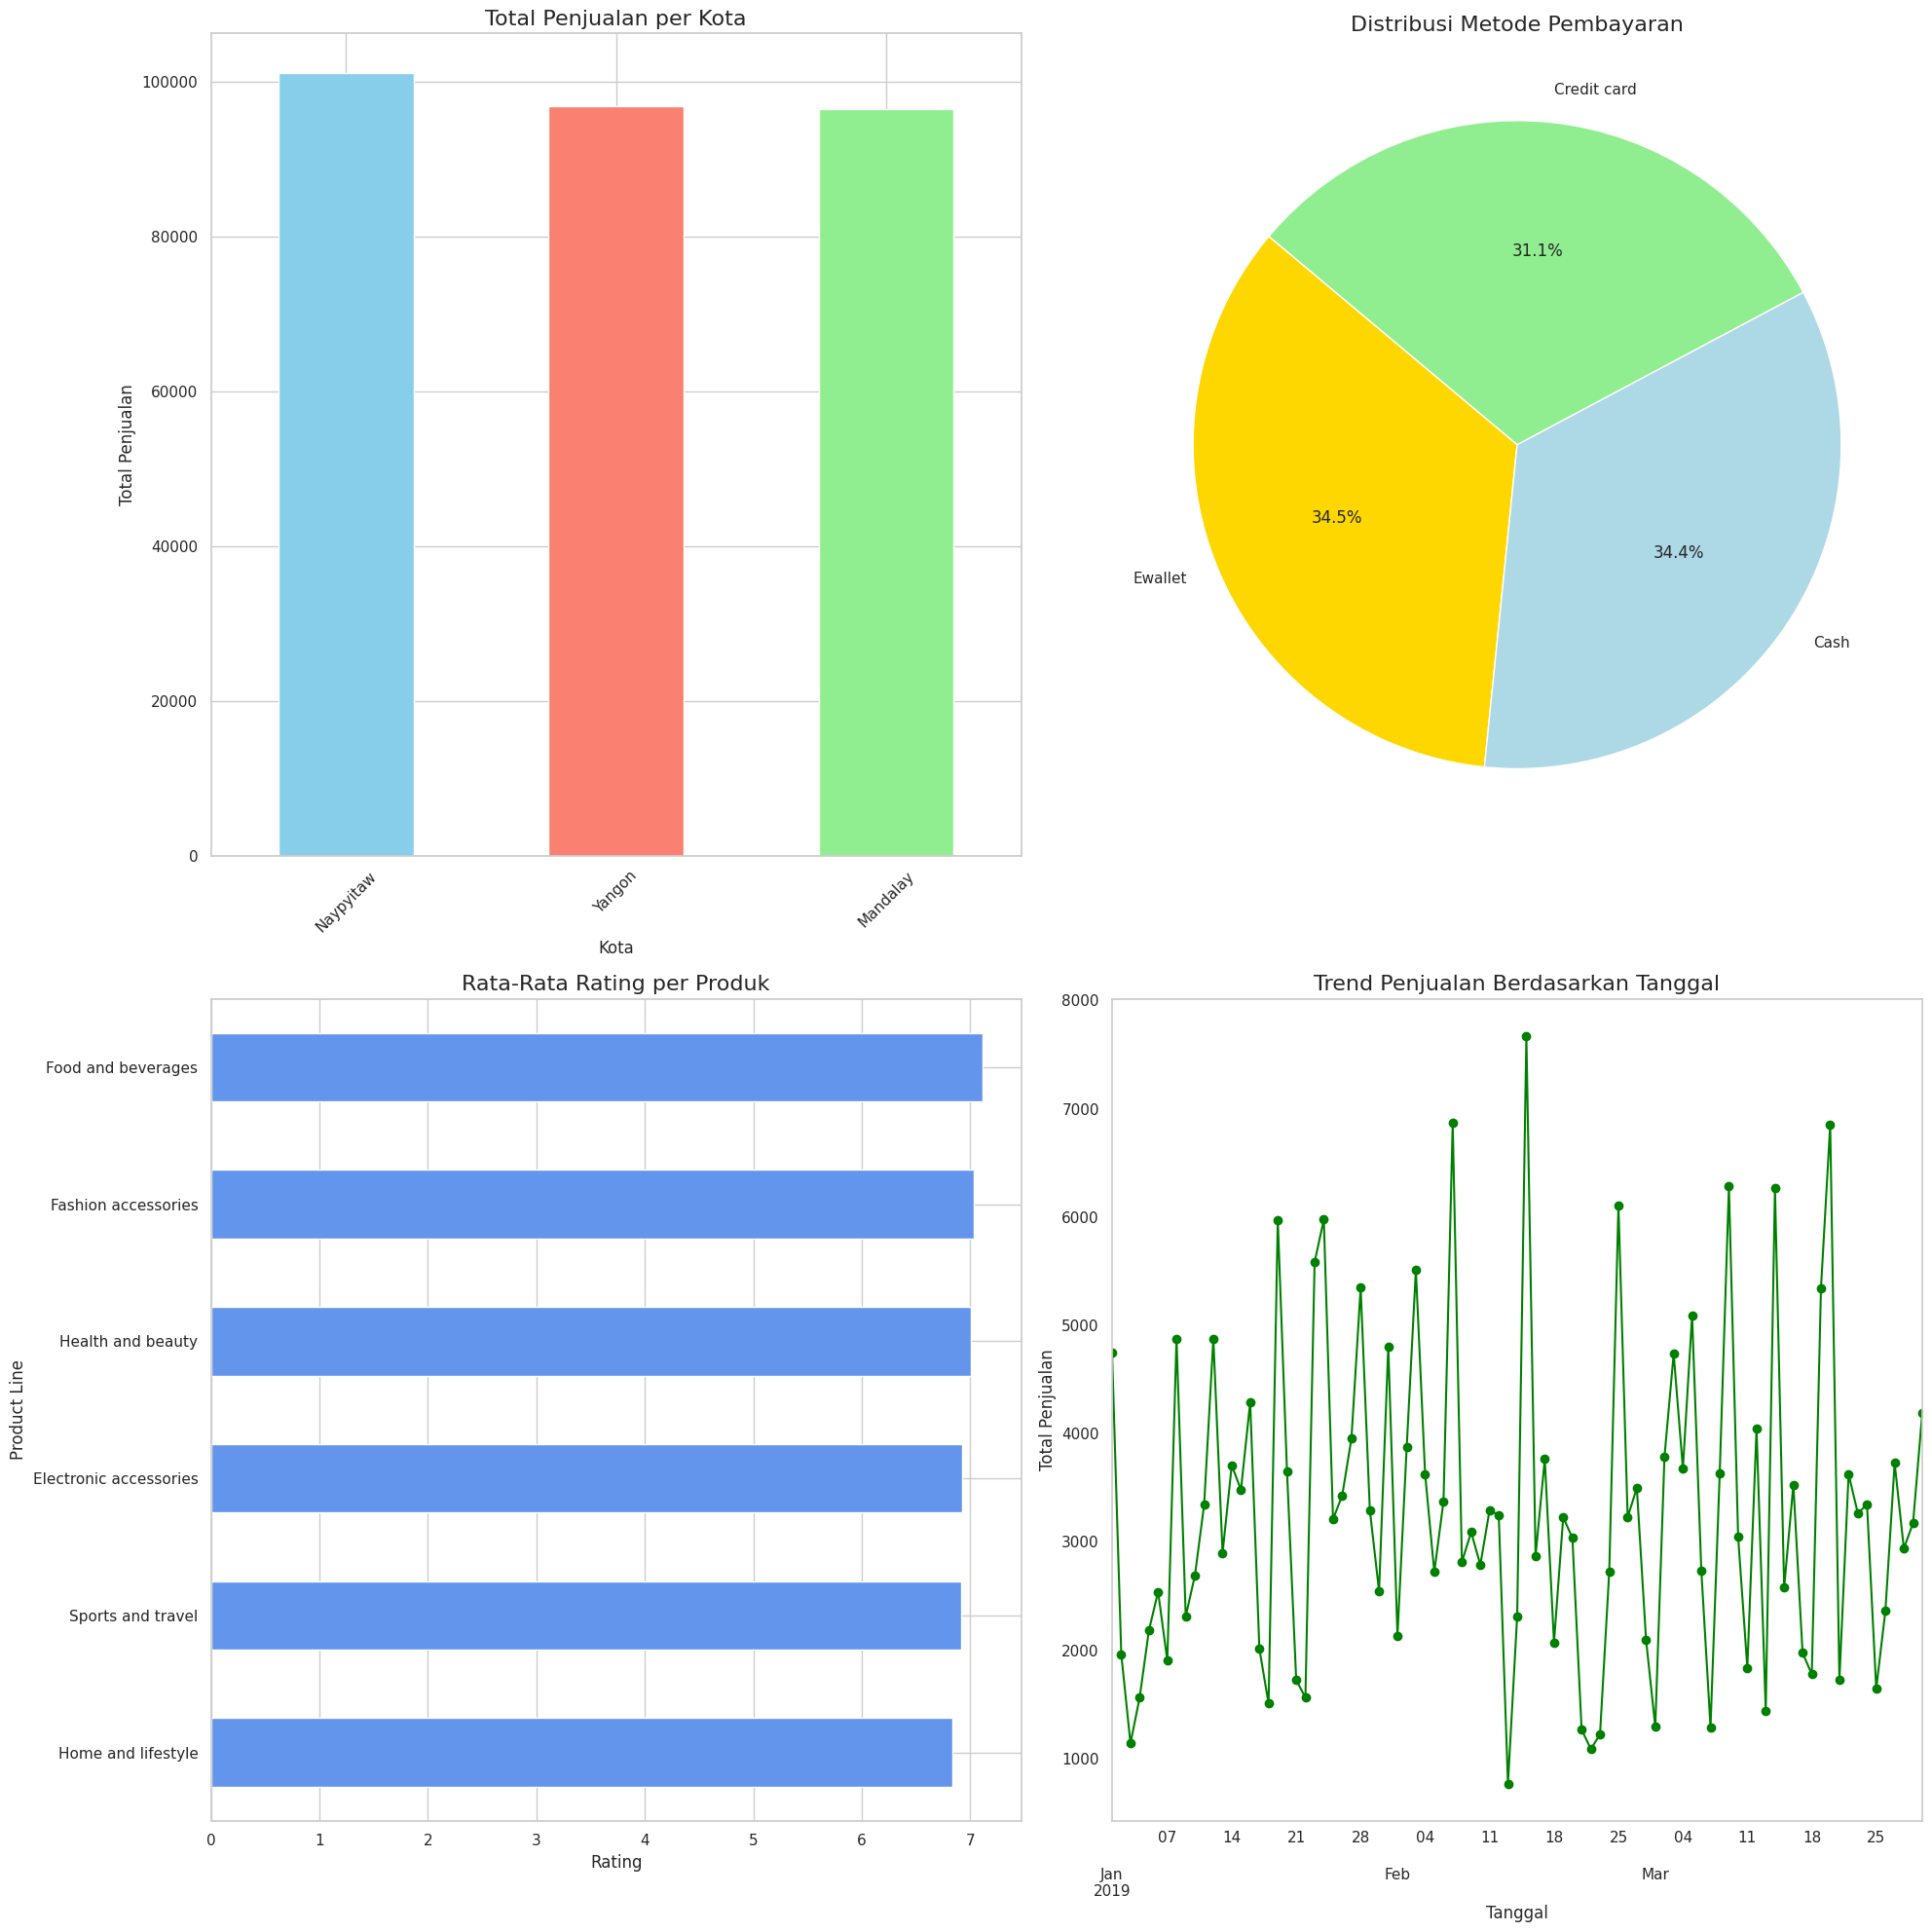

In [ ]:
# --- Membersihkan Data ---
# Menghapus kolom yang tidak diperlukan
columns_to_drop = ["Unnamed: 12", "Unnamed: 13", "Unnamed: 14"]
data_cleaned = data.drop(columns=[col for col in columns_to_drop if col in data.columns])

# Memastikan kolom 'Total' berupa string
data_cleaned['Total'] = data_cleaned['Total'].astype(str)

# Menghapus karakter non-numerik
data_cleaned['Total'] = data_cleaned['Total'].str.replace(r'[^\d.]', '', regex=True)

# Mengubah ke tipe numerik dan menangani nilai kosong
data_cleaned['Total'] = pd.to_numeric(data_cleaned['Total'], errors='coerce').fillna(0)

# Menampilkan contoh data untuk memastikan keberhasilan pembersihan
print(data_cleaned['Total'].head())
print(data_cleaned['Total'].dtype)
# Mengubah kolom 'Date' menjadi format datetime
data_cleaned['Date'] = pd.to_datetime(data_cleaned['Date'], errors='coerce')

# Mengisi nilai kosong pada kolom 'Rating' dengan rata-rata
if 'Rating' in data_cleaned.columns:
    data_cleaned['Rating'] = data_cleaned['Rating'].fillna(data_cleaned['Rating'].mean())

# Menampilkan informasi data
print(data_cleaned.info())

# --- Membuat Dashboard ---
# Menyesuaikan gaya visualisasi
sns.set(style="whitegrid")

plt.figure(figsize=(20, 20))

# 1. Total Penjualan per Kota
plt.subplot(2, 2, 1)
sales_per_city = data_cleaned.groupby("City")["Total"].sum().sort_values(ascending=False)
sales_per_city.plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'])
plt.title("Total Penjualan per Kota", fontsize=16)
plt.xlabel("Kota", fontsize=12)
plt.ylabel("Total Penjualan", fontsize=12)
plt.xticks(rotation=45)

# 2. Distribusi Metode Pembayaran
plt.subplot(2, 2, 2)
if "Payment" in data_cleaned.columns:
    payment_distribution = data_cleaned["Payment"].value_counts()
    payment_distribution.plot(kind='pie', autopct='%1.1f%%',
                               colors=['gold', 'lightblue', 'lightgreen'], startangle=140)
    plt.title("Distribusi Metode Pembayaran", fontsize=16)
    plt.ylabel("")

# 3. Rata-Rata Rating per Produk
plt.subplot(2, 2, 3)
if "Product line" in data_cleaned.columns:
    avg_rating = data_cleaned.groupby("Product line")["Rating"].mean().sort_values()
    avg_rating.plot(kind='barh', color='cornflowerblue')
    plt.title("Rata-Rata Rating per Produk", fontsize=16)
    plt.xlabel("Rating", fontsize=12)
    plt.ylabel("Product Line", fontsize=12)

# 4. Trend Penjualan Berdasarkan Tanggal
plt.subplot(2, 2, 4)
sales_trend = data_cleaned.groupby("Date")["Total"].sum()
sales_trend.plot(kind='line', color='green', marker='o')
plt.title("Trend Penjualan Berdasarkan Tanggal", fontsize=16)
plt.xlabel("Tanggal", fontsize=12)
plt.ylabel("Total Penjualan", fontsize=12)
plt.grid()

# Menampilkan dashboard
plt.tight_layout()
plt.show()

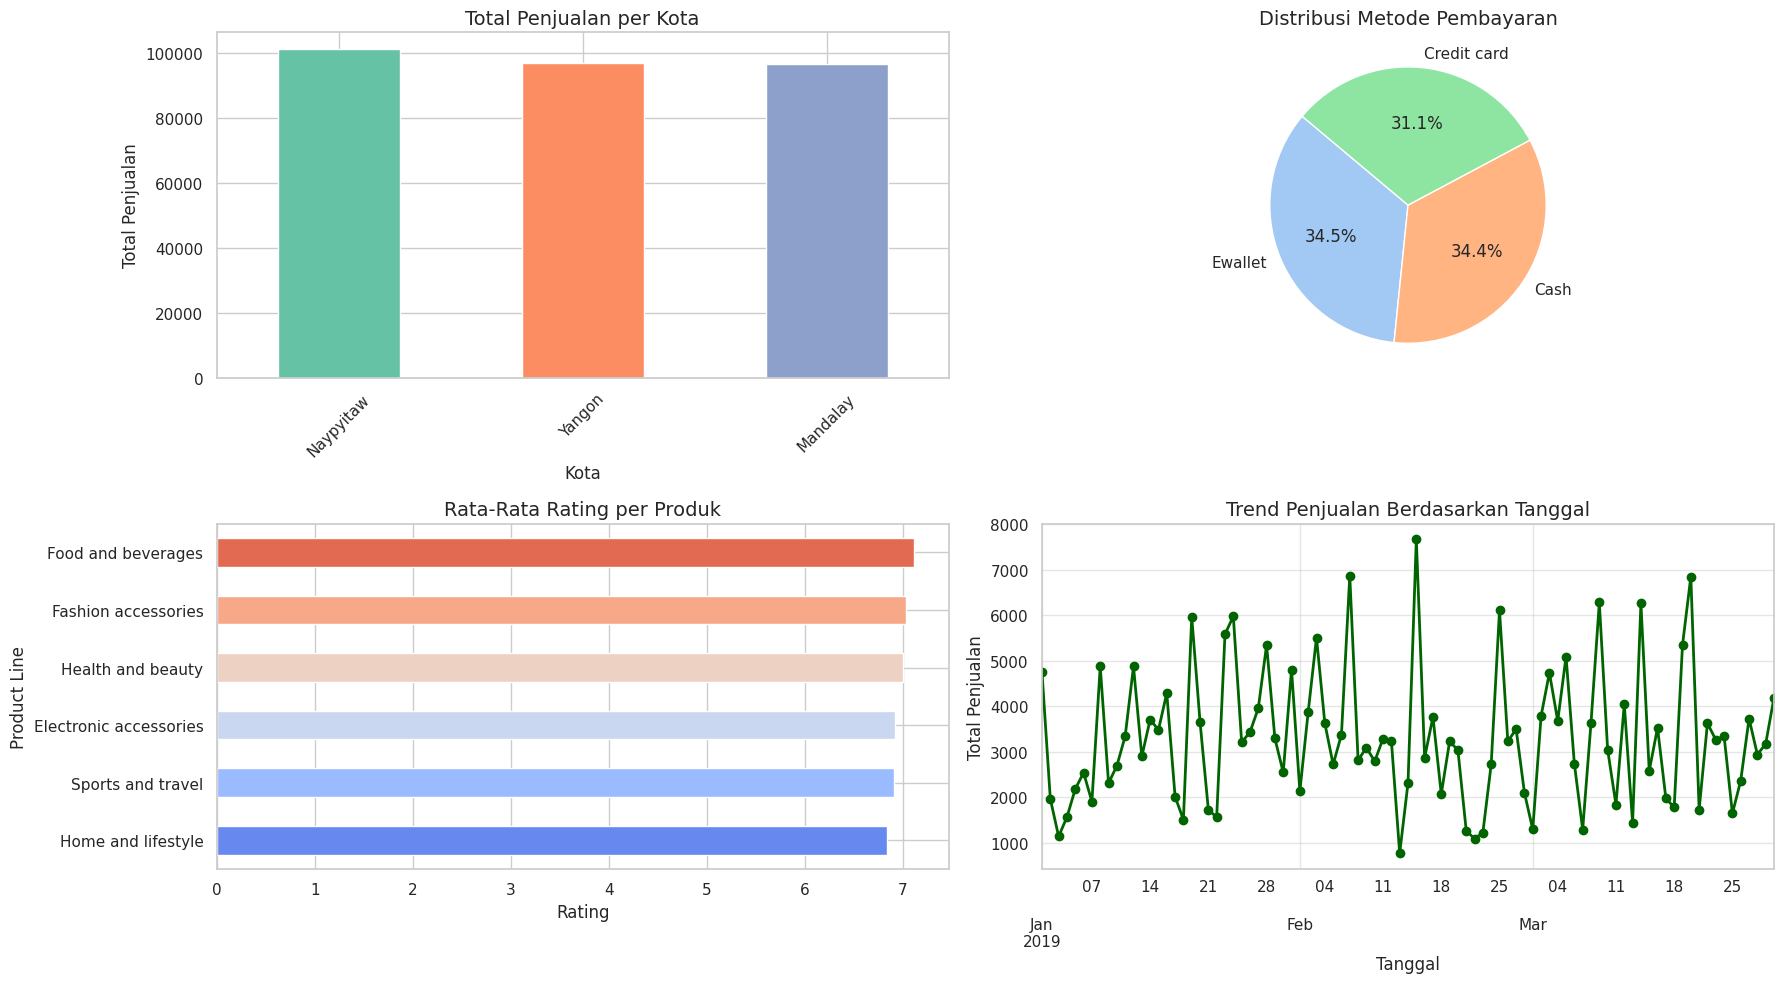

In [ ]:
# --- Membuat Dashboard ---
# Menyesuaikan gaya visualisasi
sns.set_theme(style="whitegrid")
custom_palette = sns.color_palette("viridis", as_cmap=True)

# Mengatur ukuran dan orientasi dashboard (landscape)
plt.figure(figsize=(18, 10))  # Lebar 18, tinggi 10

# 1. Total Penjualan per Kota
plt.subplot(2, 2, 1)
sales_per_city = data_cleaned.groupby("City")["Total"].sum().sort_values(ascending=False)
sales_per_city.plot(kind='bar', color=sns.color_palette("Set2"))
plt.title("Total Penjualan per Kota", fontsize=14)
plt.xlabel("Kota", fontsize=12)
plt.ylabel("Total Penjualan", fontsize=12)
plt.xticks(rotation=45)

# 2. Distribusi Metode Pembayaran
plt.subplot(2, 2, 2)
if "Payment" in data_cleaned.columns:
    payment_distribution = data_cleaned["Payment"].value_counts()
    payment_distribution.plot(kind='pie', autopct='%1.1f%%',
                               colors=sns.color_palette("pastel"), startangle=140)
    plt.title("Distribusi Metode Pembayaran", fontsize=14)
    plt.ylabel("")

# 3. Rata-Rata Rating per Produk
plt.subplot(2, 2, 3)
if "Product line" in data_cleaned.columns:
    avg_rating = data_cleaned.groupby("Product line")["Rating"].mean().sort_values()
    avg_rating.plot(kind='barh', color=sns.color_palette("coolwarm", len(avg_rating)))
    plt.title("Rata-Rata Rating per Produk", fontsize=14)
    plt.xlabel("Rating", fontsize=12)
    plt.ylabel("Product Line", fontsize=12)

# 4. Trend Penjualan Berdasarkan Tanggal
plt.subplot(2, 2, 4)
sales_trend = data_cleaned.groupby("Date")["Total"].sum()
sales_trend.plot(kind='line', color='darkgreen', marker='o', linewidth=2)
plt.title("Trend Penjualan Berdasarkan Tanggal", fontsize=14)
plt.xlabel("Tanggal", fontsize=12)
plt.ylabel("Total Penjualan", fontsize=12)
plt.grid(alpha=0.5)

# Menyempurnakan tata letak
plt.tight_layout()

# Menampilkan dashboard
plt.show()

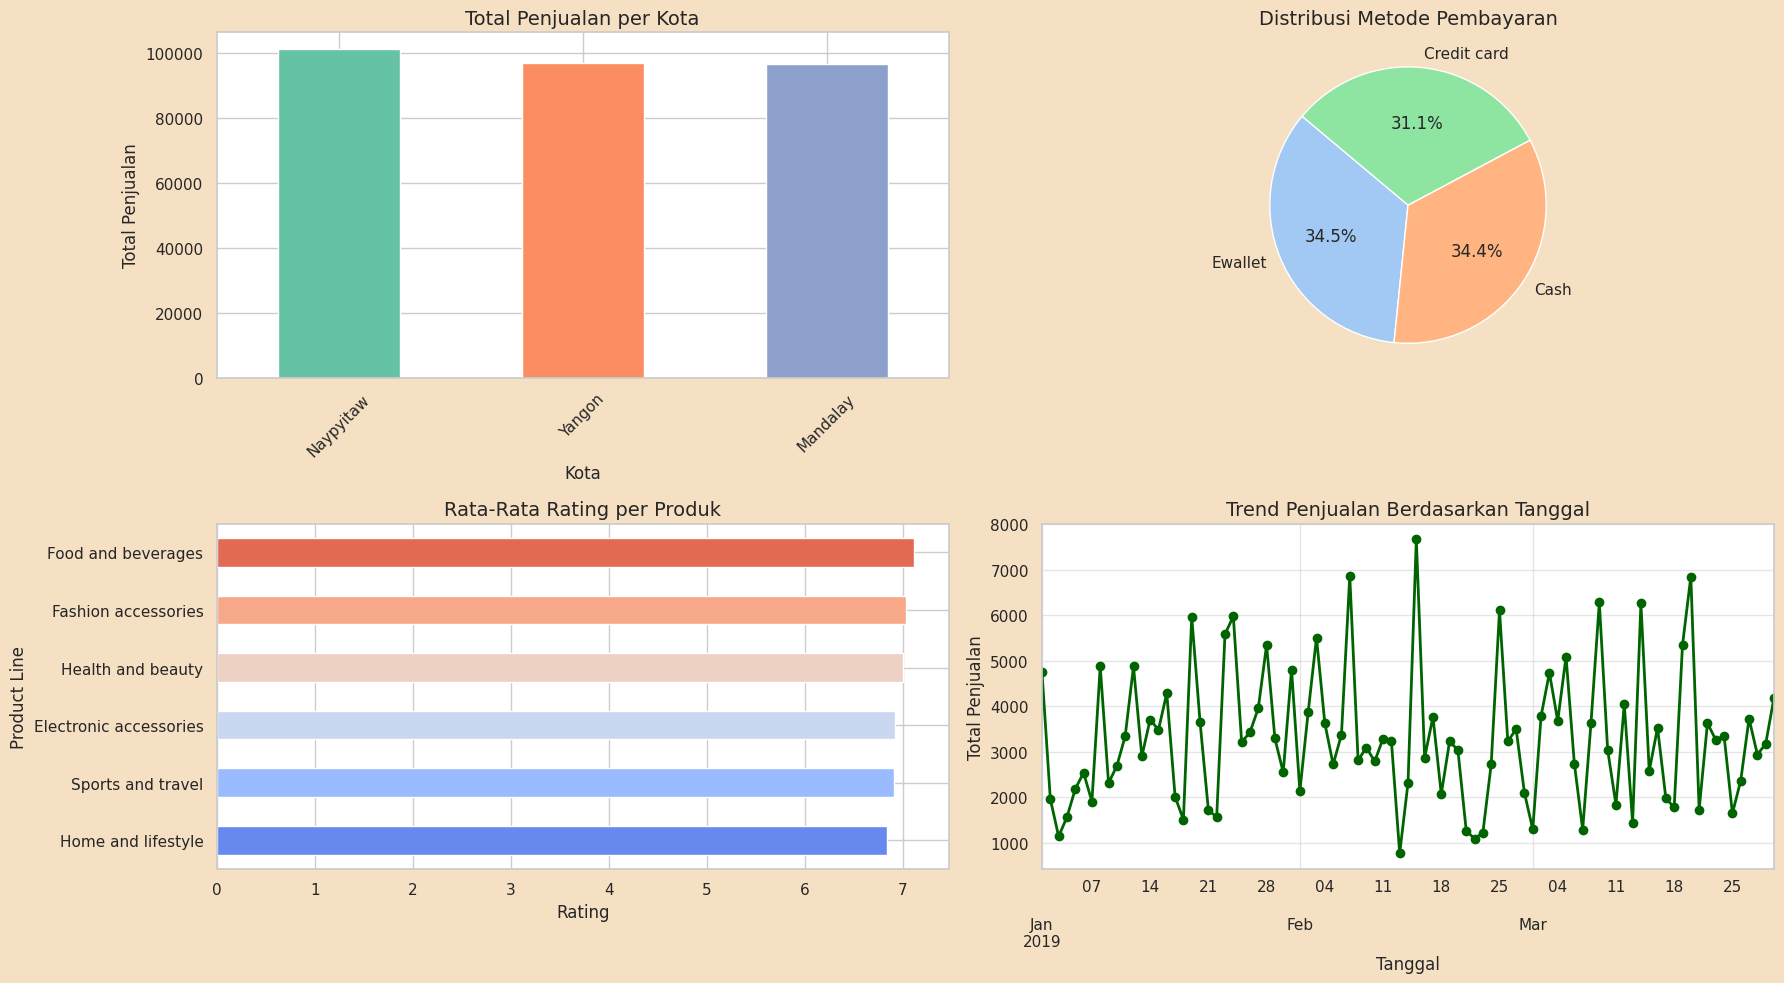

In [ ]:
# --- Membuat Dashboard ---
# Menyesuaikan gaya visualisasi
sns.set_theme(style="whitegrid")
custom_palette = sns.color_palette("viridis", as_cmap=True)

# Mengatur ukuran dan orientasi dashboard (landscape)
plt.figure(figsize=(18, 10))  # Lebar 18, tinggi 10

# Mengatur warna background menjadi coklat pastel
plt.gcf().patch.set_facecolor('#f5e0c3')  # Hex color untuk coklat pastel

# 1. Total Penjualan per Kota
plt.subplot(2, 2, 1)
sales_per_city = data_cleaned.groupby("City")["Total"].sum().sort_values(ascending=False)
sales_per_city.plot(kind='bar', color=sns.color_palette("Set2"))
plt.title("Total Penjualan per Kota", fontsize=14)
plt.xlabel("Kota", fontsize=12)
plt.ylabel("Total Penjualan", fontsize=12)
plt.xticks(rotation=45)

# 2. Distribusi Metode Pembayaran
plt.subplot(2, 2, 2)
if "Payment" in data_cleaned.columns:
    payment_distribution = data_cleaned["Payment"].value_counts()
    payment_distribution.plot(kind='pie', autopct='%1.1f%%',
                               colors=sns.color_palette("pastel"), startangle=140)
    plt.title("Distribusi Metode Pembayaran", fontsize=14)
    plt.ylabel("")

# 3. Rata-Rata Rating per Produk
plt.subplot(2, 2, 3)
if "Product line" in data_cleaned.columns:
    avg_rating = data_cleaned.groupby("Product line")["Rating"].mean().sort_values()
    avg_rating.plot(kind='barh', color=sns.color_palette("coolwarm", len(avg_rating)))
    plt.title("Rata-Rata Rating per Produk", fontsize=14)
    plt.xlabel("Rating", fontsize=12)
    plt.ylabel("Product Line", fontsize=12)

# 4. Trend Penjualan Berdasarkan Tanggal
plt.subplot(2, 2, 4)
sales_trend = data_cleaned.groupby("Date")["Total"].sum()
sales_trend.plot(kind='line', color='darkgreen', marker='o', linewidth=2)
plt.title("Trend Penjualan Berdasarkan Tanggal", fontsize=14)
plt.xlabel("Tanggal", fontsize=12)
plt.ylabel("Total Penjualan", fontsize=12)
plt.grid(alpha=0.5)

# Menyempurnakan tata letak
plt.tight_layout()

# Menampilkan dashboard
plt.show()

In [ ]:
from matplotlib import patheffects as pe  # Untuk shadow efek pada grafik

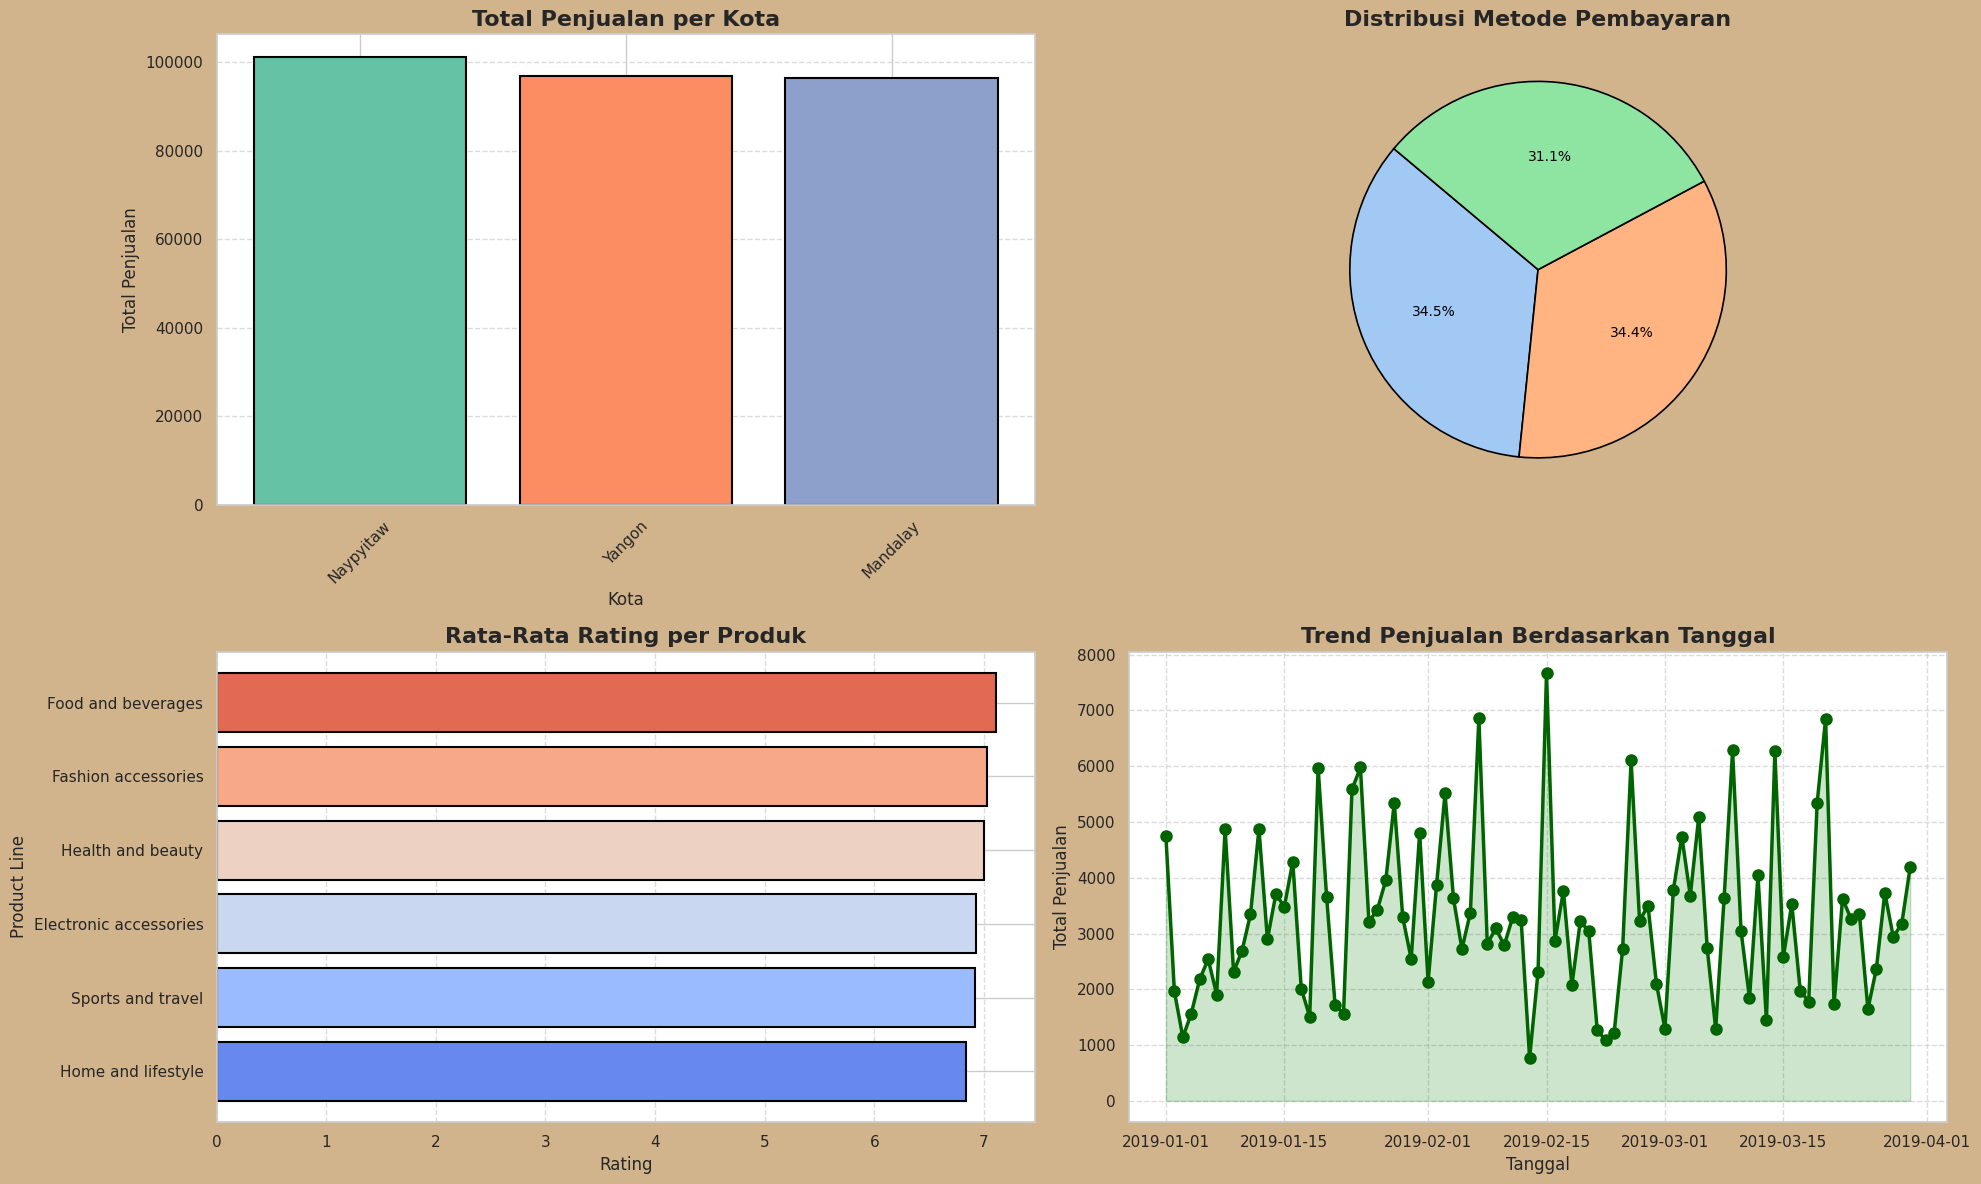

In [ ]:
# --- Membuat Dashboard ---
# Menyesuaikan gaya visualisasi
sns.set_theme(style="whitegrid")
custom_palette = sns.color_palette("viridis", as_cmap=True)

# Mengatur ukuran dan orientasi dashboard (landscape)
plt.figure(figsize=(20, 12))  # Lebar 20, tinggi 12

# Mengatur warna background menjadi coklat yang lebih gelap
plt.gcf().patch.set_facecolor('#d2b48c')  # Hex color untuk coklat gelap (tan brown)

# 1. Total Penjualan per Kota
plt.subplot(2, 2, 1)
sales_per_city = data_cleaned.groupby("City")["Total"].sum().sort_values(ascending=False)
bars = plt.bar(sales_per_city.index, sales_per_city, color=sns.color_palette("Set2"), edgecolor="black")
plt.title("Total Penjualan per Kota", fontsize=16, fontweight='bold')
plt.xlabel("Kota", fontsize=12)
plt.ylabel("Total Penjualan", fontsize=12)
plt.xticks(rotation=45)
# Menambahkan shadow
for bar in bars:
    bar.set_zorder(2)
    bar.set_linewidth(1.5)
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=1)

# 2. Distribusi Metode Pembayaran
plt.subplot(2, 2, 2)
if "Payment" in data_cleaned.columns:
    payment_distribution = data_cleaned["Payment"].value_counts()
    wedges, texts, autotexts = plt.pie(payment_distribution, autopct='%1.1f%%',
                                       colors=sns.color_palette("pastel"), startangle=140,
                                       wedgeprops={'edgecolor': 'black', 'linewidth': 1.2})
    plt.title("Distribusi Metode Pembayaran", fontsize=16, fontweight='bold')
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontsize(10)

# 3. Rata-Rata Rating per Produk
plt.subplot(2, 2, 3)
if "Product line" in data_cleaned.columns:
    avg_rating = data_cleaned.groupby("Product line")["Rating"].mean().sort_values()
    bars = plt.barh(avg_rating.index, avg_rating, color=sns.color_palette("coolwarm", len(avg_rating)), edgecolor="black")
    plt.title("Rata-Rata Rating per Produk", fontsize=16, fontweight='bold')
    plt.xlabel("Rating", fontsize=12)
    plt.ylabel("Product Line", fontsize=12)
    # Menambahkan shadow
    for bar in bars:
        bar.set_zorder(2)
        bar.set_linewidth(1.5)
    plt.grid(axis='x', linestyle='--', alpha=0.7, zorder=1)

# 4. Trend Penjualan Berdasarkan Tanggal
plt.subplot(2, 2, 4)
sales_trend = data_cleaned.groupby("Date")["Total"].sum()
plt.plot(sales_trend.index, sales_trend.values, color='darkgreen', marker='o', linewidth=2.5, markersize=8)
plt.title("Trend Penjualan Berdasarkan Tanggal", fontsize=16, fontweight='bold')
plt.xlabel("Tanggal", fontsize=12)
plt.ylabel("Total Penjualan", fontsize=12)
plt.grid(linestyle='--', alpha=0.7)
plt.fill_between(sales_trend.index, sales_trend.values, color='green', alpha=0.2)

# Menyempurnakan tata letak
plt.tight_layout()

# Menampilkan dashboard
plt.show()

In [ ]:
from matplotlib.ticker import FuncFormatter

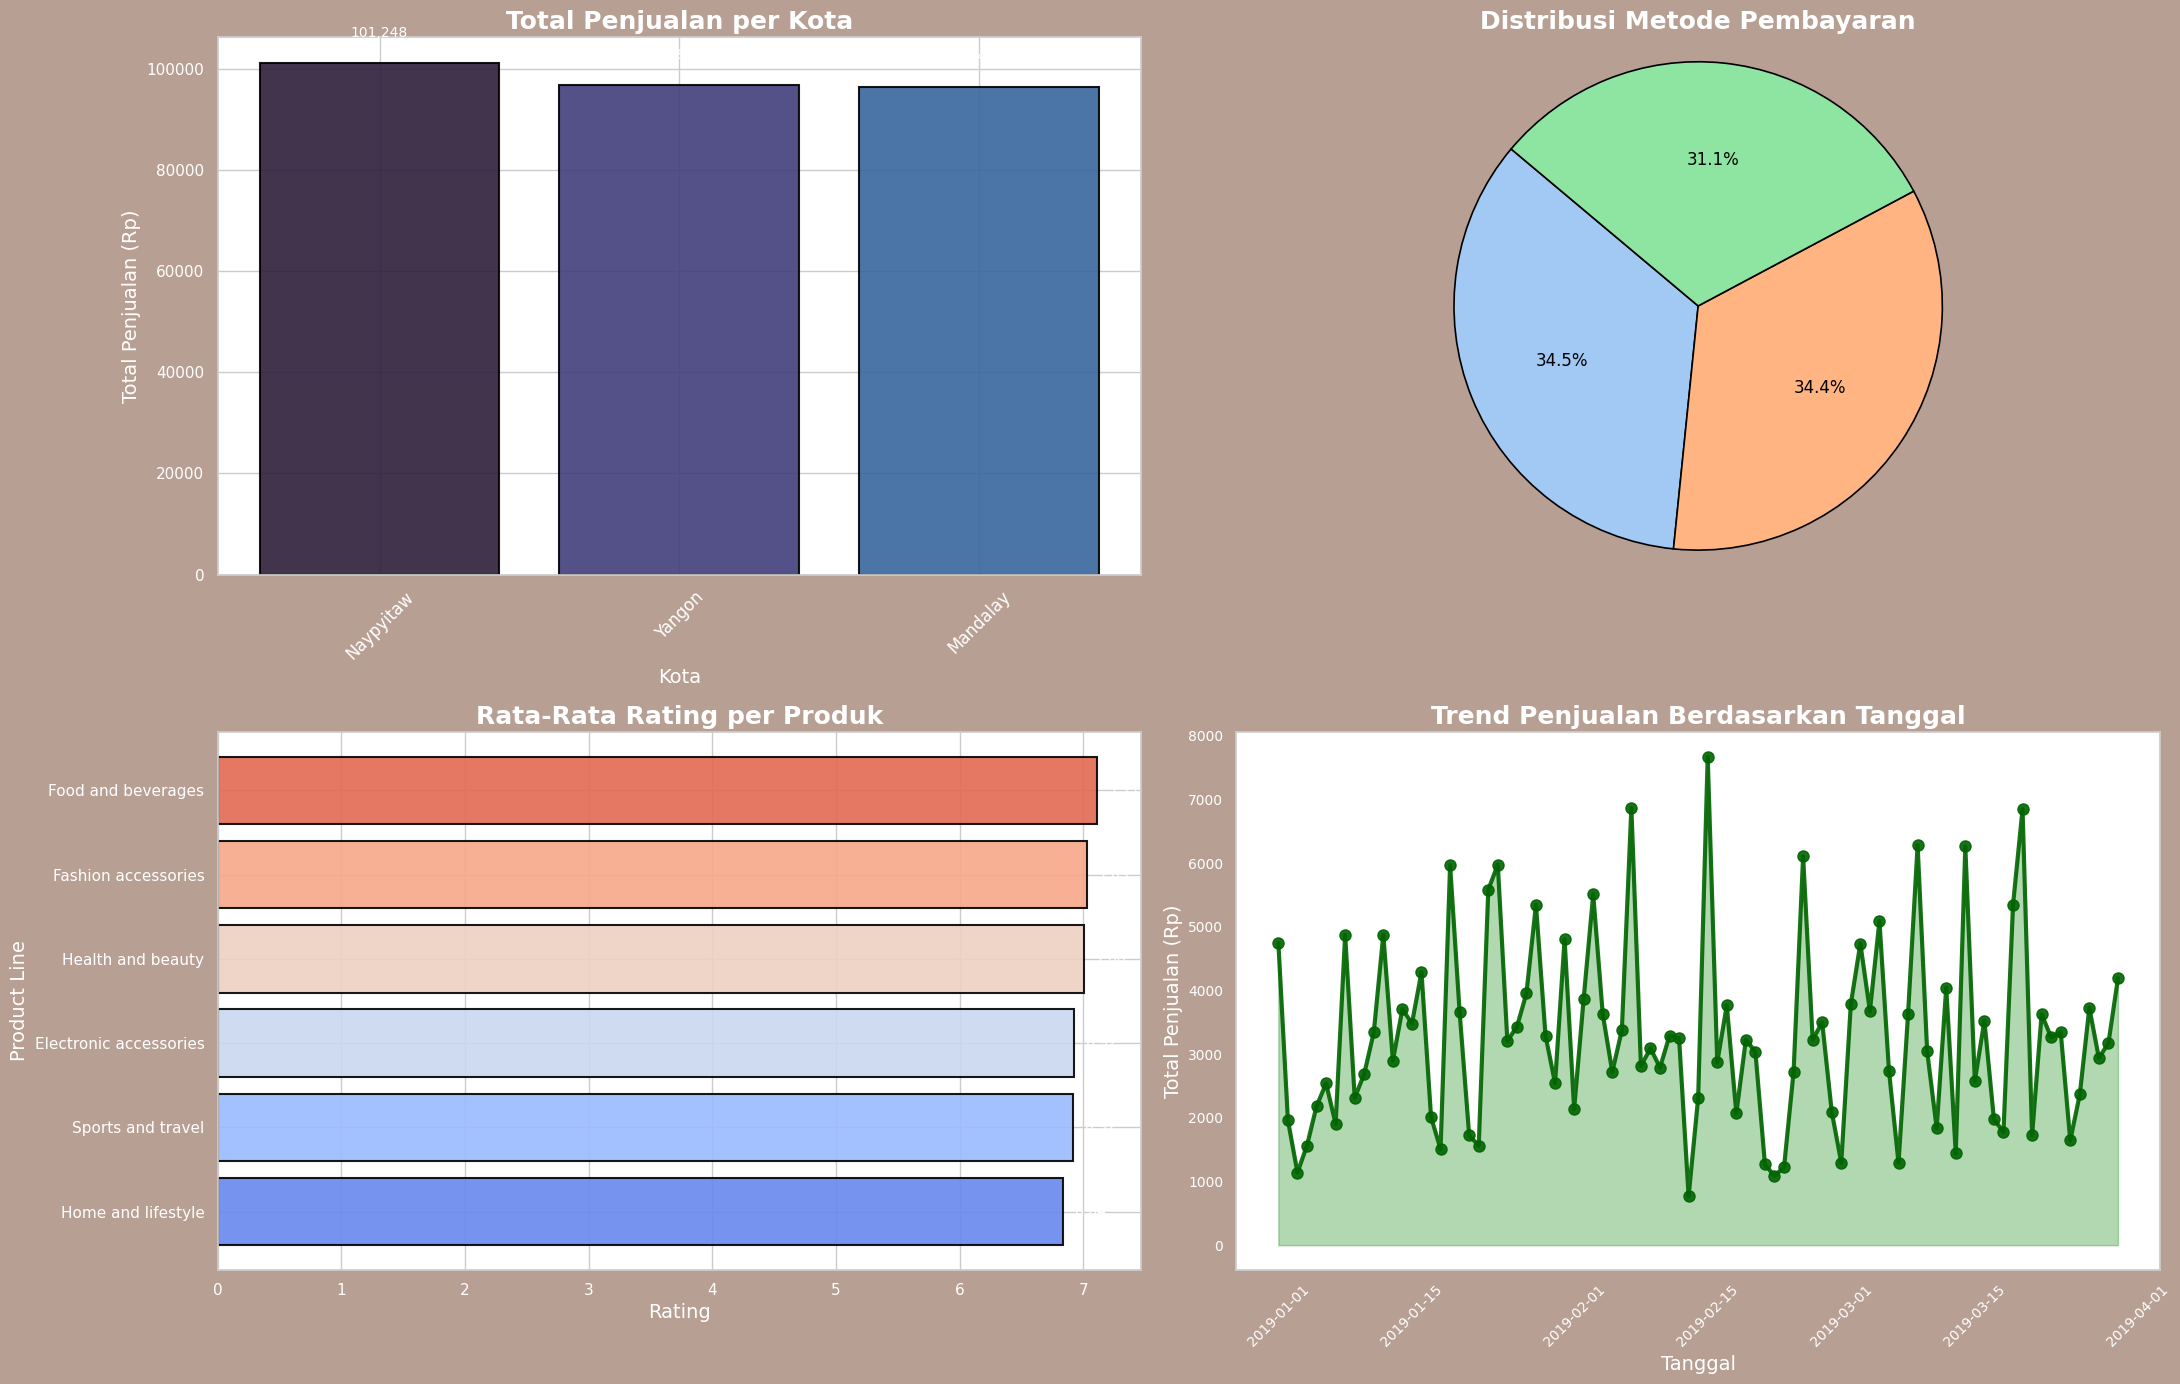

In [ ]:
# --- Membuat Dashboard ---
# Mengatur gaya dan warna
sns.set_theme(style="whitegrid")
plt.figure(figsize=(22, 14))  # Dashboard landscape besar

# Background coklat pastel gelap
plt.gcf().patch.set_facecolor('#b89f94')  # Warna pastel coklat

# Warna dan efek shadow untuk setiap grafik
shadow_params = dict(edgecolor="black", linewidth=1.5, zorder=2, alpha=0.9)

# 1. Total Penjualan per Kota
plt.subplot(2, 2, 1)
sales_per_city = data_cleaned.groupby("City")["Total"].sum().sort_values(ascending=False)
bars = plt.bar(sales_per_city.index, sales_per_city, color=sns.color_palette("mako"), **shadow_params)
plt.title("Total Penjualan per Kota", fontsize=18, fontweight='bold', color='white')
plt.xlabel("Kota", fontsize=14, color='white')
plt.ylabel("Total Penjualan (Rp)", fontsize=14, color='white')
plt.xticks(rotation=45, fontsize=12, color='white')
plt.yticks(color='white')

# Menambahkan label pada setiap bar
for i, val in enumerate(sales_per_city):
    plt.text(i, val + 0.05 * max(sales_per_city), f"{int(val):,}", ha='center', fontsize=10, color='white')

# 2. Distribusi Metode Pembayaran
plt.subplot(2, 2, 2)
if "Payment" in data_cleaned.columns:
    payment_distribution = data_cleaned["Payment"].value_counts()
    wedges, texts, autotexts = plt.pie(payment_distribution, autopct='%1.1f%%',
                                       colors=sns.color_palette("pastel"), startangle=140,
                                       wedgeprops={'edgecolor': 'black', 'linewidth': 1.2})
    plt.title("Distribusi Metode Pembayaran", fontsize=18, fontweight='bold', color='white')
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontsize(12)
    plt.axis('equal')  # Membuat lingkaran proporsional

# 3. Rata-Rata Rating per Produk
plt.subplot(2, 2, 3)
if "Product line" in data_cleaned.columns:
    avg_rating = data_cleaned.groupby("Product line")["Rating"].mean().sort_values()
    bars = plt.barh(avg_rating.index, avg_rating, color=sns.color_palette("coolwarm", len(avg_rating)), **shadow_params)
    plt.title("Rata-Rata Rating per Produk", fontsize=18, fontweight='bold', color='white')
    plt.xlabel("Rating", fontsize=14, color='white')
    plt.ylabel("Product Line", fontsize=14, color='white')
    plt.xticks(color='white')
    plt.yticks(color='white')

# Menambahkan nilai pada setiap bar
for i, val in enumerate(avg_rating):
    plt.text(val + 0.1, i, f"{val:.2f}", va='center', fontsize=10, color='white')

# 4. Trend Penjualan Berdasarkan Tanggal
plt.subplot(2, 2, 4)
sales_trend = data_cleaned.groupby("Date")["Total"].sum()
plt.plot(sales_trend.index, sales_trend.values, color='darkgreen', marker='o', linewidth=3, markersize=8, alpha=0.9)
plt.title("Trend Penjualan Berdasarkan Tanggal", fontsize=18, fontweight='bold', color='white')
plt.xlabel("Tanggal", fontsize=14, color='white')
plt.ylabel("Total Penjualan (Rp)", fontsize=14, color='white')
plt.grid(linestyle='--', alpha=0.7, color='white')
plt.xticks(fontsize=10, color='white', rotation=45)
plt.yticks(fontsize=10, color='white')
plt.fill_between(sales_trend.index, sales_trend.values, color='green', alpha=0.3)

# Menyempurnakan tata letak
plt.tight_layout()
plt.show()

In [ ]:
pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.9 MB/s eta 0:00:00


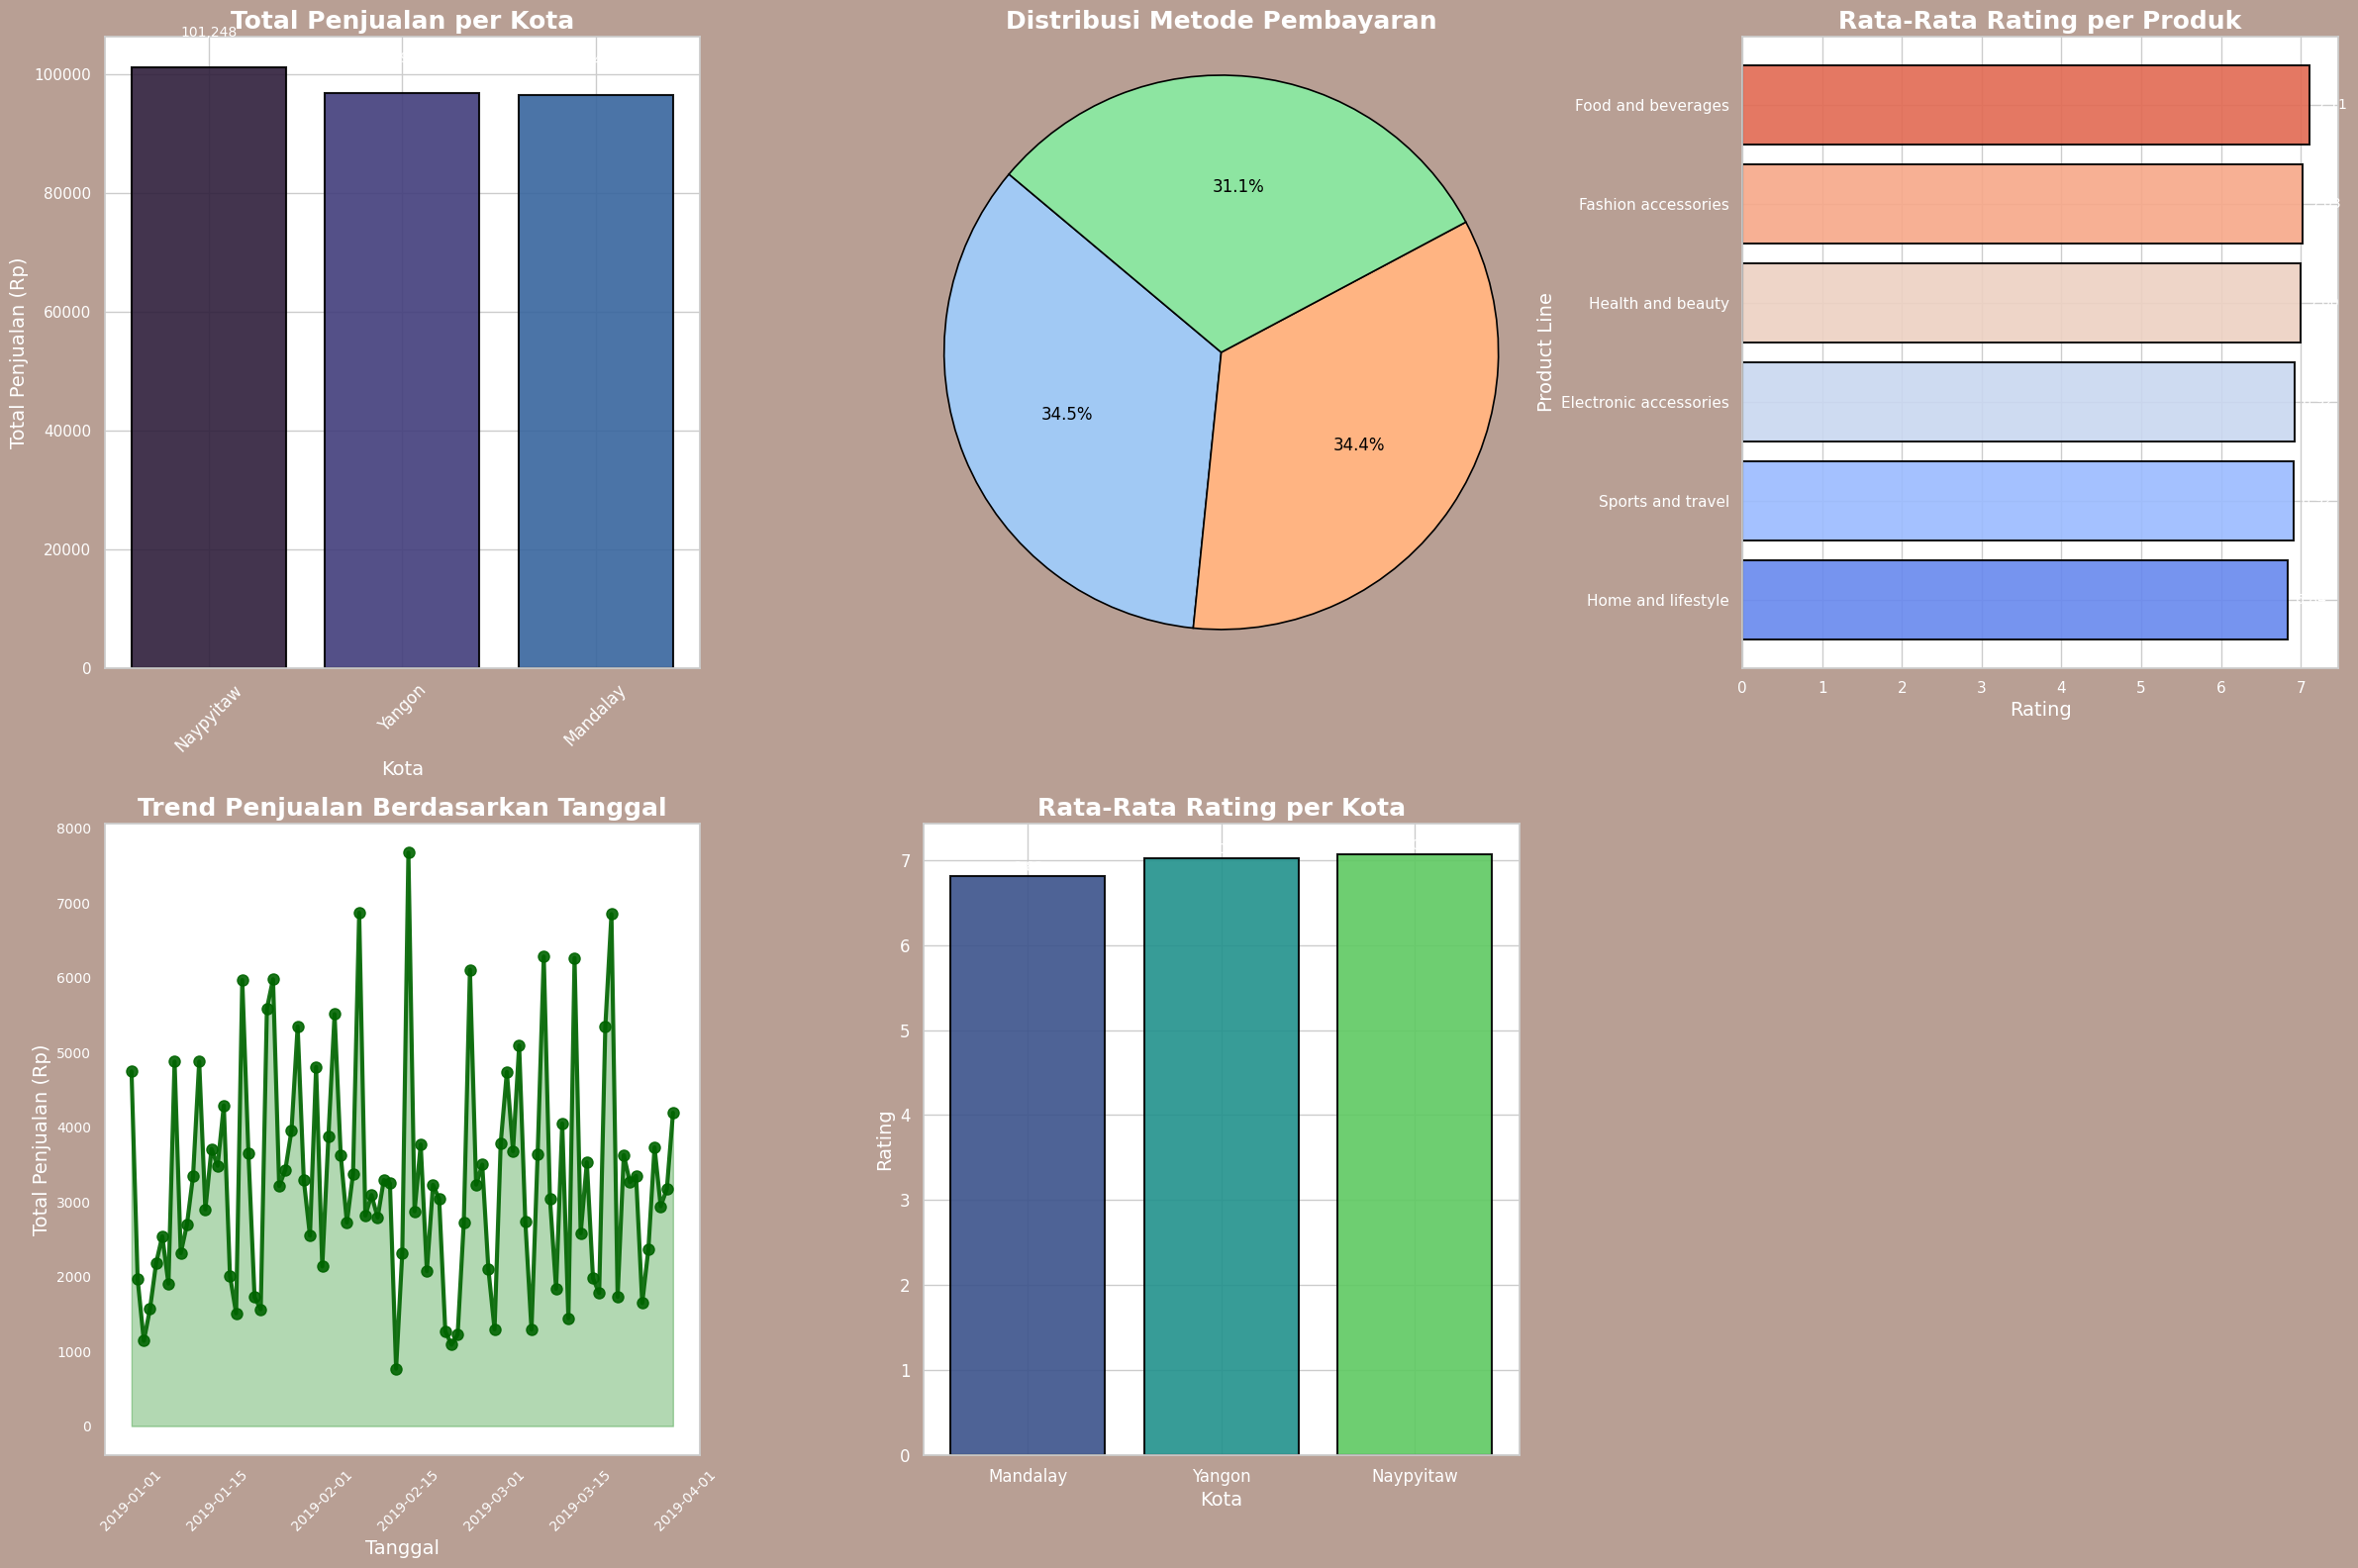

In [ ]:
# --- Membuat Dashboard ---
# Mengatur gaya dan warna
sns.set_theme(style="whitegrid")
plt.figure(figsize=(24, 16))  # Dashboard landscape besar

# Background coklat pastel gelap
plt.gcf().patch.set_facecolor('#b89f94')  # Warna pastel coklat

# Warna dan efek shadow untuk setiap grafik
shadow_params = dict(edgecolor="black", linewidth=1.5, zorder=2, alpha=0.9)

# 1. Total Penjualan per Kota
plt.subplot(2, 3, 1)
sales_per_city = data_cleaned.groupby("City")["Total"].sum().sort_values(ascending=False)
bars = plt.bar(sales_per_city.index, sales_per_city, color=sns.color_palette("mako"), **shadow_params)
plt.title("Total Penjualan per Kota", fontsize=18, fontweight='bold', color='white')
plt.xlabel("Kota", fontsize=14, color='white')
plt.ylabel("Total Penjualan (Rp)", fontsize=14, color='white')
plt.xticks(rotation=45, fontsize=12, color='white')
plt.yticks(color='white')

# Menambahkan label pada setiap bar
for i, val in enumerate(sales_per_city):
    plt.text(i, val + 0.05 * max(sales_per_city), f"{int(val):,}", ha='center', fontsize=10, color='white')

# 2. Distribusi Metode Pembayaran
plt.subplot(2, 3, 2)
if "Payment" in data_cleaned.columns:
    payment_distribution = data_cleaned["Payment"].value_counts()
    wedges, texts, autotexts = plt.pie(payment_distribution, autopct='%1.1f%%',
                                       colors=sns.color_palette("pastel"), startangle=140,
                                       wedgeprops={'edgecolor': 'black', 'linewidth': 1.2})
    plt.title("Distribusi Metode Pembayaran", fontsize=18, fontweight='bold', color='white')
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontsize(12)
    plt.axis('equal')  # Membuat lingkaran proporsional

# 3. Rata-Rata Rating per Produk
plt.subplot(2, 3, 3)
if "Product line" in data_cleaned.columns:
    avg_rating = data_cleaned.groupby("Product line")["Rating"].mean().sort_values()
    bars = plt.barh(avg_rating.index, avg_rating, color=sns.color_palette("coolwarm", len(avg_rating)), **shadow_params)
    plt.title("Rata-Rata Rating per Produk", fontsize=18, fontweight='bold', color='white')
    plt.xlabel("Rating", fontsize=14, color='white')
    plt.ylabel("Product Line", fontsize=14, color='white')
    plt.xticks(color='white')
    plt.yticks(color='white')

# Menambahkan nilai pada setiap bar
for i, val in enumerate(avg_rating):
    plt.text(val + 0.1, i, f"{val:.2f}", va='center', fontsize=10, color='white')

# 4. Trend Penjualan Berdasarkan Tanggal
plt.subplot(2, 3, 4)
sales_trend = data_cleaned.groupby("Date")["Total"].sum()
plt.plot(sales_trend.index, sales_trend.values, color='darkgreen', marker='o', linewidth=3, markersize=8, alpha=0.9)
plt.title("Trend Penjualan Berdasarkan Tanggal", fontsize=18, fontweight='bold', color='white')
plt.xlabel("Tanggal", fontsize=14, color='white')
plt.ylabel("Total Penjualan (Rp)", fontsize=14, color='white')
plt.grid(linestyle='--', alpha=0.7, color='white')
plt.xticks(fontsize=10, color='white', rotation=45)
plt.yticks(fontsize=10, color='white')
plt.fill_between(sales_trend.index, sales_trend.values, color='green', alpha=0.3)

# 5. Rating per Kota
plt.subplot(2, 3, 5)
if "City" in data_cleaned.columns and "Rating" in data_cleaned.columns:
    avg_rating_city = data_cleaned.groupby("City")["Rating"].mean().sort_values()
    bars = plt.bar(avg_rating_city.index, avg_rating_city, color=sns.color_palette("viridis", len(avg_rating_city)), **shadow_params)
    plt.title("Rata-Rata Rating per Kota", fontsize=18, fontweight='bold', color='white')
    plt.xlabel("Kota", fontsize=14, color='white')
    plt.ylabel("Rating", fontsize=14, color='white')
    plt.xticks(fontsize=12, color='white')
    plt.yticks(fontsize=12, color='white')

# Menambahkan nilai pada setiap bar
for i, val in enumerate(avg_rating_city):
    plt.text(i, val + 0.05, f"{val:.2f}", ha='center', fontsize=10, color='white')

# Menyempurnakan tata letak
plt.tight_layout()
plt.show()

In [ ]:
!pip install dash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 14.4 MB/s eta 0:00:00
  Attempting uninstall: Werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3


In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from dash import Dash, dcc, html, Input, Output

In [ ]:
# Inisialisasi aplikasi Dash
app = Dash(__name__)

# Layout Dashboard
app.layout = html.Div(
    style={"backgroundColor": "#b89f94", "padding": "20px"},
    children=[
        html.H1("📊 Dashboard Penjualan Supermarket", style={"textAlign": "center", "color": "white"}),

        # Dropdown untuk memilih kota
        html.Div([
            html.Label("Pilih Kota:", style={"fontSize": "18px", "color": "white"}),
            dcc.Dropdown(
                id="city-dropdown",
                options=[{"label": city, "value": city} for city in data_cleaned["City"].unique()],
                value=data_cleaned["City"].unique()[0],
                style={"width": "50%"}
            )
        ]),

        # Grafik interaktif
        html.Div([
            dcc.Graph(id="sales-per-city"),
            dcc.Graph(id="payment-distribution"),
            dcc.Graph(id="sales-trend"),
            dcc.Graph(id="avg-rating-product"),
            dcc.Graph(id="rating-per-city"),
        ])
    ]
)

# Callback untuk memperbarui grafik
@app.callback(
    Output("sales-per-city", "figure"),
    Input("city-dropdown", "value")
)
def update_sales_per_city(selected_city):
    sales_per_city = data_cleaned.groupby("City")["Total"].sum().reset_index()
    fig = px.bar(
        sales_per_city,
        x="City",
        y="Total",
        color="Total",
        title="Total Penjualan per Kota",
        color_continuous_scale="cividis"
    )
    fig.update_layout(
        plot_bgcolor="#b89f94",
        paper_bgcolor="#b89f94",
        font_color="white"
    )
    return fig


@app.callback(
    Output("payment-distribution", "figure"),
    Input("city-dropdown", "value")
)
def update_payment_distribution(selected_city):
    payment_distribution = data_cleaned[data_cleaned["City"] == selected_city]["Payment"].value_counts().reset_index()
    payment_distribution.columns = ["Payment Method", "Count"]
    fig = px.pie(
        payment_distribution,
        names="Payment Method",
        values="Count",
        title=f"Distribusi Metode Pembayaran di {selected_city}",
        color_discrete_sequence=px.colors.sequential.Plasma
    )
    return fig


@app.callback(
    Output("sales-trend", "figure"),
    Input("city-dropdown", "value")
)
def update_sales_trend(selected_city):
    sales_trend = data_cleaned[data_cleaned["City"] == selected_city].groupby("Date")["Total"].sum().reset_index()
    fig = px.line(
        sales_trend,
        x="Date",
        y="Total",
        title=f"Trend Penjualan di {selected_city}",
        markers=True
    )
    fig.update_traces(line=dict(color="green", width=3), marker=dict(size=8))
    fig.update_layout(
        plot_bgcolor="#b89f94",
        paper_bgcolor="#b89f94",
        font_color="white"
    )
    return fig


@app.callback(
    Output("avg-rating-product", "figure"),
    Input("city-dropdown", "value")
)
def update_avg_rating_product(selected_city):
    avg_rating = data_cleaned.groupby("Product line")["Rating"].mean().sort_values().reset_index()
    fig = px.bar(
        avg_rating,
        x="Rating",
        y="Product line",
        title="Rata-Rata Rating per Produk",
        color="Rating",
        color_continuous_scale="sunset",
        orientation="h"
    )
    fig.update_layout(
        plot_bgcolor="#b89f94",
        paper_bgcolor="#b89f94",
        font_color="white"
    )
    return fig


@app.callback(
    Output("rating-per-city", "figure"),
    Input("city-dropdown", "value")
)
def update_rating_per_city(selected_city):
    avg_rating_city = data_cleaned.groupby("City")["Rating"].mean().reset_index()
    fig = px.bar(
        avg_rating_city,
        x="City",
        y="Rating",
        title="Rata-Rata Rating per Kota",
        color="Rating",
        color_continuous_scale="magma"
    )
    fig.update_layout(
        plot_bgcolor="#b89f94",
        paper_bgcolor="#b89f94",
        font_color="white"
    )
    return fig


# Menjalankan aplikasi
if __name__ == "__main__":
    app.run_server(debug=True)

<IPython.core.display.Javascript object>

In [ ]:
# Inisialisasi aplikasi Dash
app = Dash(__name__)

# Layout Dashboard
app.layout = html.Div(
    style={"backgroundColor": "#b89f94", "padding": "20px"},
    children=[
        html.H1("📊 Dashboard Penjualan Supermarket", style={"textAlign": "center", "color": "white"}),

        # Dropdown untuk memilih kota
        html.Div(
            style={"display": "flex", "justifyContent": "center", "marginBottom": "20px"},
            children=[
                html.Label("Pilih Kota:", style={"fontSize": "18px", "color": "white", "marginRight": "10px"}),
                dcc.Dropdown(
                    id="city-dropdown",
                    options=[{"label": city, "value": city} for city in data_cleaned["City"].unique()],
                    value=data_cleaned["City"].unique()[0],
                    style={"width": "30%"}
                )
            ]
        ),

        # Membuat layout grafik dalam format landscape
        html.Div(
            style={"display": "flex", "flexDirection": "row", "justifyContent": "space-around"},
            children=[
                # Grafik 1 dan 2 dalam satu baris
                html.Div(
                    style={"flex": "1", "margin": "10px"},
                    children=[dcc.Graph(id="sales-per-city")]
                ),
                html.Div(
                    style={"flex": "1", "margin": "10px"},
                    children=[dcc.Graph(id="payment-distribution")]
                ),
            ]
        ),

        html.Div(
            style={"display": "flex", "flexDirection": "row", "justifyContent": "space-around"},
            children=[
                # Grafik 3 dan 4 dalam satu baris
                html.Div(
                    style={"flex": "1", "margin": "10px"},
                    children=[dcc.Graph(id="sales-trend")]
                ),
                html.Div(
                    style={"flex": "1", "margin": "10px"},
                    children=[dcc.Graph(id="avg-rating-product")]
                ),
            ]
        ),

        html.Div(
            style={"display": "flex", "justifyContent": "center", "marginTop": "20px"},
            children=[
                # Grafik 5 (Rating per Kota)
                html.Div(
                    style={"flex": "1", "margin": "10px", "maxWidth": "50%"},
                    children=[dcc.Graph(id="rating-per-city")]
                ),
            ]
        )
    ]
)

# Callback untuk memperbarui grafik (sama seperti sebelumnya)
@app.callback(
    Output("sales-per-city", "figure"),
    Input("city-dropdown", "value")
)
def update_sales_per_city(selected_city):
    sales_per_city = data_cleaned.groupby("City")["Total"].sum().reset_index()
    fig = px.bar(
        sales_per_city,
        x="City",
        y="Total",
        color="Total",
        title="Total Penjualan per Kota",
        color_continuous_scale="cividis"
    )
    fig.update_layout(
        plot_bgcolor="#b89f94",
        paper_bgcolor="#b89f94",
        font_color="white"
    )
    return fig


@app.callback(
    Output("payment-distribution", "figure"),
    Input("city-dropdown", "value")
)
def update_payment_distribution(selected_city):
    payment_distribution = data_cleaned[data_cleaned["City"] == selected_city]["Payment"].value_counts().reset_index()
    payment_distribution.columns = ["Payment Method", "Count"]
    fig = px.pie(
        payment_distribution,
        names="Payment Method",
        values="Count",
        title=f"Distribusi Metode Pembayaran di {selected_city}",
        color_discrete_sequence=px.colors.sequential.Plasma
    )
    return fig


@app.callback(
    Output("sales-trend", "figure"),
    Input("city-dropdown", "value")
)
def update_sales_trend(selected_city):
    sales_trend = data_cleaned[data_cleaned["City"] == selected_city].groupby("Date")["Total"].sum().reset_index()
    fig = px.line(
        sales_trend,
        x="Date",
        y="Total",
        title=f"Trend Penjualan di {selected_city}",
        markers=True
    )
    fig.update_traces(line=dict(color="green", width=3), marker=dict(size=8))
    fig.update_layout(
        plot_bgcolor="#b89f94",
        paper_bgcolor="#b89f94",
        font_color="white"
    )
    return fig


@app.callback(
    Output("avg-rating-product", "figure"),
    Input("city-dropdown", "value")
)
def update_avg_rating_product(selected_city):
    avg_rating = data_cleaned.groupby("Product line")["Rating"].mean().sort_values().reset_index()
    fig = px.bar(
        avg_rating,
        x="Rating",
        y="Product line",
        title="Rata-Rata Rating per Produk",
        color="Rating",
        color_continuous_scale="sunset",
        orientation="h"
    )
    fig.update_layout(
        plot_bgcolor="#b89f94",
        paper_bgcolor="#b89f94",
        font_color="white"
    )
    return fig


@app.callback(
    Output("rating-per-city", "figure"),
    Input("city-dropdown", "value")
)
def update_rating_per_city(selected_city):
    avg_rating_city = data_cleaned.groupby("City")["Rating"].mean().reset_index()
    fig = px.bar(
        avg_rating_city,
        x="City",
        y="Rating",
        title="Rata-Rata Rating per Kota",
        color="Rating",
        color_continuous_scale="magma"
    )
    fig.update_layout(
        plot_bgcolor="#b89f94",
        paper_bgcolor="#b89f94",
        font_color="white"
    )
    return fig


# Menjalankan aplikasi
if __name__ == "__main__":
    app.run_server(debug=True)

<IPython.core.display.Javascript object>